In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
x = np.linspace(0, 2 * np.pi, 100)

def f(x, a, b):
    return a * np.exp(-b * x)

a = 2.0
b = 0.5

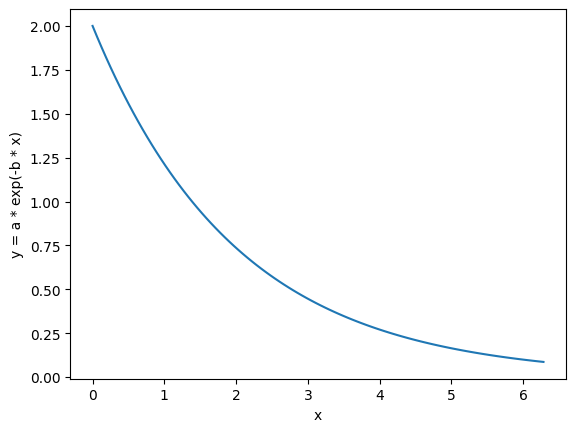

In [6]:
y = f(x, a, b)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y = a * exp(-b * x)")

plt.savefig("exponential_decay.pdf")
plt.show()

In [7]:
# sigma decreases linearly from 2 to 0.2 as x increases
sigma = np.linspace(2, 0.2, 100)

noise = np.random.normal(0, sigma)
y_scattered = y + noise

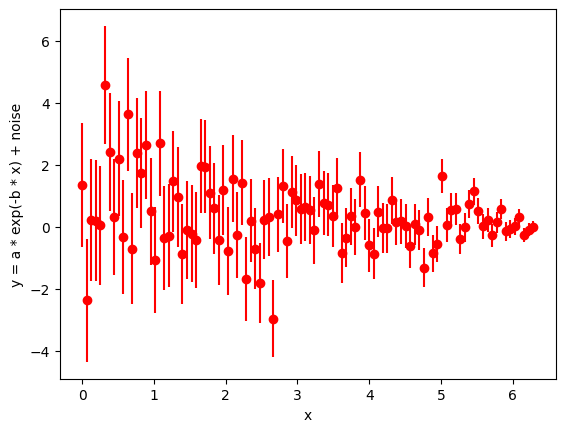

In [8]:

plt.errorbar(x, y_scattered, yerr=sigma, fmt="o", color="red")
plt.xlabel("x")
plt.ylabel("y = a * exp(-b * x) + noise")

plt.savefig("exponential_decay_scatter.pdf")
plt.show()

In [9]:
# model 1: exponential decay
def model_exp(x, a, b):
    return a * np.exp(-b * x)

# model 2: power law
def model_pow(x, a, b):
    return a / (x ** b)

# fit exponential to all points
popt_exp, _ = curve_fit(model_exp, x, y_scattered, sigma=sigma)

popt_pow, _ = curve_fit(model_pow, x[1:], y_scattered[1:], sigma=sigma[1:])

a_exp, b_exp = popt_exp
a_pow, b_pow = popt_pow

print(f"Exponential fit: a = {a_exp:.4f}, b = {b_exp:.4f}")
print(f"Power law fit:   a = {a_pow:.4f}, b = {b_pow:.4f}")

Exponential fit: a = 1.1235, b = 0.4710
Power law fit:   a = 0.2786, b = 0.4655


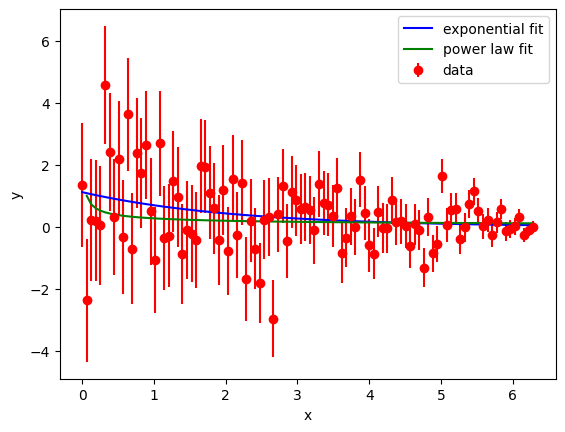

In [10]:
plt.errorbar(x, y_scattered, yerr=sigma, fmt="o", color="red", label="data")
plt.plot(x, model_exp(x, *popt_exp), color="blue", label="exponential fit")
plt.plot(x[1:], model_pow(x[1:], *popt_pow), color="green", label="power law fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.savefig("exponential_decay_fits.pdf")
plt.show()